<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/07_MedReasoner_Cluster_Aware_Statistical_Synthesis_FAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Imports and configuration
from pathlib import Path
import json, time, warnings
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import rankdata, spearmanr

SEED = 2026
N_BOOT = 2000
N_PERM = 10000
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("Seed:", SEED)
print("Cluster bootstrap draws:", N_BOOT)
print("Permutation draws:", N_PERM)

Seed: 2026
Cluster bootstrap draws: 2000
Permutation draws: 10000


In [2]:
# CELL 2 — Mount Drive and locate previous outputs
from google.colab import drive
DRIVE = Path("/content/drive")
if not (DRIVE / "MyDrive").exists():
    drive.mount(str(DRIVE), force_remount=False)

ROOT = DRIVE / "MyDrive" / "MedReasoner_SAM_2026"
MANIFEST_DIR = ROOT / "01_manifests"
EVAL_DIR = ROOT / "05_evaluation"
FIG_DIR = ROOT / "06_figures"
SYNTH_DIR = ROOT / "07_statistical_synthesis_fast"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

ASSET_MANIFEST = MANIFEST_DIR / "medreasoner_vlm_asset_manifest.csv"
NATURAL_QWEN = EVAL_DIR / "02_blinded_failure_recognition_qwen25vl7b_case_level_evaluation.csv"
NATURAL_PHI  = EVAL_DIR / "03_independent_vlm_replication_phi35vision_case_level_evaluation.csv"
CF_QWEN = EVAL_DIR / "04_counterfactual_qc_qwen25vl7b_case_level_evaluation.csv"
CF_PHI  = EVAL_DIR / "05_counterfactual_qc_phi35vision_case_level_evaluation.csv"
ABLATION_PAIRED = EVAL_DIR / "06_visual_evidence_ablation_qwen25vl7b_paired_case_table.csv"

required = [ASSET_MANIFEST, NATURAL_QWEN, NATURAL_PHI, CF_QWEN, CF_PHI, ABLATION_PAIRED]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required previous outputs:\n" + "\n".join(missing))

print("All required outputs found.")
print("Output folder:", SYNTH_DIR)

Mounted at /content/drive
All required outputs found.
Output folder: /content/drive/MyDrive/MedReasoner_SAM_2026/07_statistical_synthesis_fast


In [3]:
# CELL 3 — Fast metric and cluster-resampling utilities
def as_bool(series):
    if series.dtype == bool:
        return series.copy()
    return series.astype(str).str.strip().str.lower().map({"true":True,"false":False,"1":True,"0":False})

def fast_binary_metrics(y, pred, score):
    y=np.asarray(y,dtype=np.int8); pred=np.asarray(pred,dtype=np.int8); score=np.asarray(score,dtype=float)
    tp=int(np.sum((y==1)&(pred==1))); tn=int(np.sum((y==0)&(pred==0)))
    fp=int(np.sum((y==0)&(pred==1))); fn=int(np.sum((y==1)&(pred==0)))
    sensitivity=tp/(tp+fn) if tp+fn else np.nan
    specificity=tn/(tn+fp) if tn+fp else np.nan
    precision=tp/(tp+fp) if tp+fp else 0.0
    f1=2*precision*sensitivity/(precision+sensitivity) if np.isfinite(sensitivity) and (precision+sensitivity)>0 else 0.0
    ba=(sensitivity+specificity)/2 if np.isfinite(sensitivity) and np.isfinite(specificity) else np.nan
    accuracy=(tp+tn)/len(y) if len(y) else np.nan
    fr=fn/(fn+tp) if fn+tp else np.nan
    fa=fp/(fp+tn) if fp+tn else np.nan
    if len(np.unique(y))==2 and np.isfinite(score).all():
        try: auroc=float(roc_auc_score(y,score))
        except: auroc=np.nan
        try: auprc=float(average_precision_score(y,score))
        except: auprc=np.nan
        brier=float(np.mean((score-y)**2))
    else:
        auroc=auprc=brier=np.nan
    return {"accuracy":float(accuracy),"balanced_accuracy":float(ba),"precision":float(precision),
            "sensitivity":float(sensitivity),"specificity":float(specificity),"f1":float(f1),
            "false_reassurance_rate":float(fr),"false_alarm_rate":float(fa),"auroc":float(auroc),
            "auprc":float(auprc),"brier":float(brier),"tp":tp,"tn":tn,"fp":fp,"fn":fn}

BOOT_METRICS=["balanced_accuracy","sensitivity","specificity","f1","false_reassurance_rate","false_alarm_rate","auroc","auprc","brier"]

def build_stratified_cluster_blocks(df, cluster_col, strata_col):
    d=df.reset_index(drop=True); structure=[]
    for stratum,sdf in d.groupby(strata_col,sort=False):
        blocks=[cdf.index.to_numpy(dtype=np.int32) for _,cdf in sdf.groupby(cluster_col,sort=False)]
        structure.append((str(stratum),blocks))
    return d,structure

def sample_cluster_rows(structure,rng):
    pieces=[]
    for _,blocks in structure:
        n=len(blocks); chosen=rng.integers(0,n,size=n)
        pieces.extend(blocks[int(j)] for j in chosen)
    return np.concatenate(pieces)

def bootstrap_single_model_fast(df,cluster_col,strata_col,truth_col,pred_col,score_col,n_boot=N_BOOT,seed=SEED,progress_name=""):
    d,structure=build_stratified_cluster_blocks(df,cluster_col,strata_col)
    y=d[truth_col].astype(int).to_numpy(); p=d[pred_col].astype(int).to_numpy(); s=pd.to_numeric(d[score_col],errors="coerce").to_numpy(dtype=float)
    point=fast_binary_metrics(y,p,s); store={m:[] for m in BOOT_METRICS}; rng=np.random.default_rng(seed); t0=time.time()
    for b in range(n_boot):
        idx=sample_cluster_rows(structure,rng); m=fast_binary_metrics(y[idx],p[idx],s[idx])
        for metric in BOOT_METRICS:
            if np.isfinite(m[metric]): store[metric].append(m[metric])
        if (b+1)%500==0: print(f"{progress_name}: {b+1:,}/{n_boot:,} ({time.time()-t0:.1f}s)")
    rows=[]
    for metric in BOOT_METRICS:
        vals=np.asarray(store[metric],dtype=float)
        rows.append({"metric":metric,"estimate":point[metric],
                     "cluster_ci95_low":float(np.percentile(vals,2.5)) if len(vals) else np.nan,
                     "cluster_ci95_high":float(np.percentile(vals,97.5)) if len(vals) else np.nan,
                     "n_boot_valid":int(len(vals))})
    return pd.DataFrame(rows)

def spearman_fast(x,y):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float); keep=np.isfinite(x)&np.isfinite(y); x=x[keep]; y=y[keep]
    if len(x)<3:return np.nan
    rx=rankdata(x); ry=rankdata(y)
    if rx.std()==0 or ry.std()==0:return np.nan
    return float(np.corrcoef(rx,ry)[0,1])

def bh_adjust(p_values):
    p=np.asarray(p_values,dtype=float); order=np.argsort(p); ranked=p[order]; n=len(p); adj=np.empty(n); running=1.0
    for i in range(n-1,-1,-1):
        running=min(running,ranked[i]*n/(i+1)); adj[i]=min(running,1.0)
    out=np.empty(n); out[order]=adj; return out

print("Fast utilities loaded.")

Fast utilities loaded.


In [4]:
# CELL 4 — Prepare natural SAM benchmark
assets=pd.read_csv(ASSET_MANIFEST)
keys=assets[["benchmark_id","domain","case_id","record_id"]].drop_duplicates("benchmark_id")
nq=pd.read_csv(NATURAL_QWEN); np_=pd.read_csv(NATURAL_PHI)
for df in [nq,np_]:
    df["true_failure"]=as_bool(df["true_failure"]); df["pred_failure"]=as_bool(df["pred_failure"])
    if "failure_score" not in df.columns:
        df["failure_score"]=pd.to_numeric(df["failure_probability"],errors="coerce")/100.0
nq=nq.merge(keys,on=["benchmark_id","domain"],how="left",validate="one_to_one")
np_=np_.merge(keys,on=["benchmark_id","domain"],how="left",validate="one_to_one")
for df in [nq,np_]:
    df["natural_cluster"]=df["domain"].astype(str)+"::"+df["case_id"].astype(str)
print("Qwen natural:",len(nq),"rows /",nq["natural_cluster"].nunique(),"clusters")
print("Phi natural:",len(np_),"rows /",np_["natural_cluster"].nunique(),"clusters")
display(nq.groupby("domain").agg(rows=("benchmark_id","size"),clusters=("natural_cluster","nunique")).reset_index())

Qwen natural: 220 rows / 103 clusters
Phi natural: 220 rows / 103 clusters


,domain,rows,clusters
0,brain_mri,94,36
1,histopathology,36,36
2,kidney_ct,90,31


In [5]:
# CELL 5 — FAST natural overall cluster CIs
natural_results=[]
for i,(model_name,df) in enumerate([("Qwen2.5-VL-7B",nq),("Phi-3.5-Vision",np_)]):
    print("\n"+"="*80+"\n"+model_name+"\n"+"="*80)
    result=bootstrap_single_model_fast(df,"natural_cluster","domain","true_failure","pred_failure","failure_score",N_BOOT,SEED+i,model_name)
    result.insert(0,"model",model_name); result.insert(0,"experiment","natural_sam_failure")
    result["n_rows"]=len(df); result["n_clusters"]=df["natural_cluster"].nunique(); natural_results.append(result)
natural_cluster_ci=pd.concat(natural_results,ignore_index=True)
natural_cluster_ci.to_csv(SYNTH_DIR/"table_natural_cluster_metrics.csv",index=False)
display(natural_cluster_ci)


Qwen2.5-VL-7B
Qwen2.5-VL-7B: 500/2,000 (1.0s)
Qwen2.5-VL-7B: 1,000/2,000 (2.1s)
Qwen2.5-VL-7B: 1,500/2,000 (3.1s)
Qwen2.5-VL-7B: 2,000/2,000 (4.1s)

Phi-3.5-Vision
Phi-3.5-Vision: 500/2,000 (1.0s)
Phi-3.5-Vision: 1,000/2,000 (2.0s)
Phi-3.5-Vision: 1,500/2,000 (3.0s)
Phi-3.5-Vision: 2,000/2,000 (4.1s)


,experiment,model,metric,estimate,cluster_ci95_low,cluster_ci95_high,n_boot_valid,n_rows,n_clusters
0,natural_sam_failure,Qwen2.5-VL-7B,balanced_accuracy,0.490330,0.457994,0.523458,2000,220,103
1,natural_sam_failure,Qwen2.5-VL-7B,sensitivity,0.926606,0.879113,0.967755,2000,220,103
2,natural_sam_failure,Qwen2.5-VL-7B,specificity,0.054054,0.018182,0.096169,2000,220,103
3,natural_sam_failure,Qwen2.5-VL-7B,f1,0.641270,0.573379,0.711111,2000,220,103
4,natural_sam_failure,Qwen2.5-VL-7B,false_reassurance_rate,0.073394,0.032245,0.120887,2000,220,103
5,natural_sam_failure,Qwen2.5-VL-7B,false_alarm_rate,0.945946,0.903831,0.981818,2000,220,103
6,natural_sam_failure,Qwen2.5-VL-7B,auroc,0.475122,0.421057,0.530522,2000,220,103
7,natural_sam_failure,Qwen2.5-VL-7B,auprc,0.483966,0.413741,0.573274,2000,220,103
8,natural_sam_failure,Qwen2.5-VL-7B,brier,0.344909,0.305132,0.388357,2000,220,103
9,natural_sam_failure,Phi-3.5-Vision,balanced_accuracy,0.478015,0.401554,0.553751,2000,220,103


In [6]:
# CELL 6 — FAST natural per-domain cluster CIs
natural_domain_results=[]
for model_i,(model_name,model_df) in enumerate([("Qwen2.5-VL-7B",nq),("Phi-3.5-Vision",np_)]):
    for domain_i,(domain,ddf) in enumerate(model_df.groupby("domain",sort=True)):
        print(f"\n{model_name} | {domain} | {len(ddf)} rows | {ddf['natural_cluster'].nunique()} clusters")
        temp=ddf.copy(); temp["_stratum"]=domain
        result=bootstrap_single_model_fast(temp,"natural_cluster","_stratum","true_failure","pred_failure","failure_score",N_BOOT,SEED+100*model_i+domain_i,f"{model_name}/{domain}")
        result.insert(0,"domain",domain); result.insert(0,"model",model_name)
        result["n_rows"]=len(ddf); result["n_clusters"]=ddf["natural_cluster"].nunique(); natural_domain_results.append(result)
natural_domain_metrics=pd.concat(natural_domain_results,ignore_index=True)
natural_domain_metrics.to_csv(SYNTH_DIR/"table_natural_domain_cluster_metrics.csv",index=False)
display(natural_domain_metrics)


Qwen2.5-VL-7B | brain_mri | 94 rows | 36 clusters
Qwen2.5-VL-7B/brain_mri: 500/2,000 (1.0s)
Qwen2.5-VL-7B/brain_mri: 1,000/2,000 (1.9s)
Qwen2.5-VL-7B/brain_mri: 1,500/2,000 (2.9s)
Qwen2.5-VL-7B/brain_mri: 2,000/2,000 (3.8s)

Qwen2.5-VL-7B | histopathology | 36 rows | 36 clusters
Qwen2.5-VL-7B/histopathology: 500/2,000 (0.9s)
Qwen2.5-VL-7B/histopathology: 1,000/2,000 (1.9s)
Qwen2.5-VL-7B/histopathology: 1,500/2,000 (2.9s)
Qwen2.5-VL-7B/histopathology: 2,000/2,000 (3.8s)

Qwen2.5-VL-7B | kidney_ct | 90 rows | 31 clusters
Qwen2.5-VL-7B/kidney_ct: 500/2,000 (0.9s)
Qwen2.5-VL-7B/kidney_ct: 1,000/2,000 (1.9s)
Qwen2.5-VL-7B/kidney_ct: 1,500/2,000 (2.8s)
Qwen2.5-VL-7B/kidney_ct: 2,000/2,000 (3.8s)

Phi-3.5-Vision | brain_mri | 94 rows | 36 clusters
Phi-3.5-Vision/brain_mri: 500/2,000 (1.0s)
Phi-3.5-Vision/brain_mri: 1,000/2,000 (1.9s)
Phi-3.5-Vision/brain_mri: 1,500/2,000 (2.9s)
Phi-3.5-Vision/brain_mri: 2,000/2,000 (3.8s)

Phi-3.5-Vision | histopathology | 36 rows | 36 clusters
Phi-3.5-Visio

,model,domain,metric,estimate,cluster_ci95_low,cluster_ci95_high,n_boot_valid,n_rows,n_clusters
0,Qwen2.5-VL-7B,brain_mri,balanced_accuracy,0.500000,0.500000,0.500000,2000,94,36
1,Qwen2.5-VL-7B,brain_mri,sensitivity,1.000000,1.000000,1.000000,2000,94,36
2,Qwen2.5-VL-7B,brain_mri,specificity,0.000000,0.000000,0.000000,2000,94,36
3,Qwen2.5-VL-7B,brain_mri,f1,0.637681,0.522503,0.743252,2000,94,36
4,Qwen2.5-VL-7B,brain_mri,false_reassurance_rate,0.000000,0.000000,0.000000,2000,94,36
5,Qwen2.5-VL-7B,brain_mri,false_alarm_rate,1.000000,1.000000,1.000000,2000,94,36
6,Qwen2.5-VL-7B,brain_mri,auroc,0.472273,0.376784,0.566029,2000,94,36
7,Qwen2.5-VL-7B,brain_mri,auprc,0.456018,0.341714,0.599806,2000,94,36
8,Qwen2.5-VL-7B,brain_mri,brier,0.310638,0.253654,0.373225,2000,94,36
9,Qwen2.5-VL-7B,histopathology,balanced_accuracy,0.612727,0.426898,0.781301,2000,36,36


In [7]:
# CELL 7 — FAST paired natural Qwen-vs-Phi bootstrap + correlations
natural_pair=nq[["benchmark_id","domain","natural_cluster","true_failure","stored_dice","pred_failure","failure_score"]].rename(columns={"pred_failure":"qwen_pred","failure_score":"qwen_score"}).merge(
    np_[["benchmark_id","pred_failure","failure_score"]].rename(columns={"pred_failure":"phi_pred","failure_score":"phi_score"}),on="benchmark_id",how="inner",validate="one_to_one")
d,structure=build_stratified_cluster_blocks(natural_pair,"natural_cluster","domain")
y=d["true_failure"].astype(int).to_numpy(); qpred=d["qwen_pred"].astype(int).to_numpy(); ppred=d["phi_pred"].astype(int).to_numpy()
qscore=d["qwen_score"].to_numpy(float); pscore=d["phi_score"].to_numpy(float); severity=1.0-pd.to_numeric(d["stored_dice"],errors="coerce").to_numpy(float)
qpoint=fast_binary_metrics(y,qpred,qscore); ppoint=fast_binary_metrics(y,ppred,pscore)
q_rho_point=spearman_fast(qscore,severity); p_rho_point=spearman_fast(pscore,severity)
rng=np.random.default_rng(SEED+700); ba=[]; auc=[]; qrhos=[]; prhos=[]; t0=time.time()
for b in range(N_BOOT):
    idx=sample_cluster_rows(structure,rng); qm=fast_binary_metrics(y[idx],qpred[idx],qscore[idx]); pm=fast_binary_metrics(y[idx],ppred[idx],pscore[idx])
    if np.isfinite(qm["balanced_accuracy"]) and np.isfinite(pm["balanced_accuracy"]):ba.append(qm["balanced_accuracy"]-pm["balanced_accuracy"])
    if np.isfinite(qm["auroc"]) and np.isfinite(pm["auroc"]):auc.append(qm["auroc"]-pm["auroc"])
    r=spearman_fast(qscore[idx],severity[idx]); s=spearman_fast(pscore[idx],severity[idx])
    if np.isfinite(r):qrhos.append(r)
    if np.isfinite(s):prhos.append(s)
    if (b+1)%500==0:print(f"Natural paired: {b+1:,}/{N_BOOT:,} ({time.time()-t0:.1f}s)")
ba=np.asarray(ba); auc=np.asarray(auc); qrhos=np.asarray(qrhos); prhos=np.asarray(prhos)
natural_model_contrasts=pd.DataFrame([
    {"comparison":"Qwen minus Phi","metric":"balanced_accuracy","estimate_difference":qpoint["balanced_accuracy"]-ppoint["balanced_accuracy"],"cluster_ci95_low":np.percentile(ba,2.5),"cluster_ci95_high":np.percentile(ba,97.5),"bootstrap_probability_gt_0":(ba>0).mean()},
    {"comparison":"Qwen minus Phi","metric":"auroc","estimate_difference":qpoint["auroc"]-ppoint["auroc"],"cluster_ci95_low":np.percentile(auc,2.5),"cluster_ci95_high":np.percentile(auc,97.5),"bootstrap_probability_gt_0":(auc>0).mean()}])
natural_correlations=pd.DataFrame([
    {"model":"Qwen2.5-VL-7B","spearman_rho":q_rho_point,"cluster_ci95_low":np.percentile(qrhos,2.5),"cluster_ci95_high":np.percentile(qrhos,97.5)},
    {"model":"Phi-3.5-Vision","spearman_rho":p_rho_point,"cluster_ci95_low":np.percentile(prhos,2.5),"cluster_ci95_high":np.percentile(prhos,97.5)}])
display(natural_model_contrasts); display(natural_correlations)

Natural paired: 500/2,000 (2.5s)
Natural paired: 1,000/2,000 (4.9s)
Natural paired: 1,500/2,000 (7.4s)
Natural paired: 2,000/2,000 (9.8s)


,comparison,metric,estimate_difference,cluster_ci95_low,cluster_ci95_high,bootstrap_probability_gt_0
0,Qwen minus Phi,balanced_accuracy,0.012315,-0.065291,0.085003,0.5980
1,Qwen minus Phi,auroc,-0.005662,-0.095639,0.083362,0.4535


,model,spearman_rho,cluster_ci95_low,cluster_ci95_high
0,Qwen2.5-VL-7B,-0.074503,-0.173189,0.032101
1,Phi-3.5-Vision,0.046117,-0.115184,0.200578


In [8]:
# CELL 8 — Prepare controlled counterfactual Qwen/Phi
cq=pd.read_csv(CF_QWEN); cp=pd.read_csv(CF_PHI)
for df in [cq,cp]:
    df["is_corrupted"]=as_bool(df["is_corrupted"]); df["pred_corrupted"]=as_bool(df["pred_corrupted"])
    if "corruption_score" not in df.columns:
        df["corruption_score"]=pd.to_numeric(df["corruption_probability"],errors="coerce")/100.0
print("Counterfactual Qwen:",len(cq),"rows /",cq["base_id"].nunique(),"bases")
print("Counterfactual Phi:",len(cp),"rows /",cp["base_id"].nunique(),"bases")

Counterfactual Qwen: 270 rows / 45 bases
Counterfactual Phi: 254 rows / 44 bases


In [9]:
# CELL 9 — FAST counterfactual cluster CIs
cf_results=[]
for i,(model_name,df) in enumerate([("Qwen2.5-VL-7B",cq),("Phi-3.5-Vision",cp)]):
    print("\n"+"="*80+"\n"+model_name+"\n"+"="*80)
    result=bootstrap_single_model_fast(df,"base_id","domain","is_corrupted","pred_corrupted","corruption_score",N_BOOT,SEED+1000+i,model_name)
    result.insert(0,"model",model_name); result.insert(0,"experiment","controlled_counterfactual")
    result["n_rows"]=len(df); result["n_clusters"]=df["base_id"].nunique(); cf_results.append(result)
cf_cluster_ci=pd.concat(cf_results,ignore_index=True)
cf_cluster_ci.to_csv(SYNTH_DIR/"table_counterfactual_cluster_metrics.csv",index=False)
display(cf_cluster_ci)


Qwen2.5-VL-7B
Qwen2.5-VL-7B: 500/2,000 (1.0s)
Qwen2.5-VL-7B: 1,000/2,000 (2.0s)
Qwen2.5-VL-7B: 1,500/2,000 (3.0s)
Qwen2.5-VL-7B: 2,000/2,000 (3.9s)

Phi-3.5-Vision
Phi-3.5-Vision: 500/2,000 (1.0s)
Phi-3.5-Vision: 1,000/2,000 (2.0s)
Phi-3.5-Vision: 1,500/2,000 (3.2s)
Phi-3.5-Vision: 2,000/2,000 (4.2s)


,experiment,model,metric,estimate,cluster_ci95_low,cluster_ci95_high,n_boot_valid,n_rows,n_clusters
0,controlled_counterfactual,Qwen2.5-VL-7B,balanced_accuracy,0.604444,0.575556,0.626667,2000,270,45
1,controlled_counterfactual,Qwen2.5-VL-7B,sensitivity,0.897778,0.875556,0.924444,2000,270,45
2,controlled_counterfactual,Qwen2.5-VL-7B,specificity,0.311111,0.266667,0.333333,2000,270,45
3,controlled_counterfactual,Qwen2.5-VL-7B,f1,0.882096,0.867257,0.896104,2000,270,45
4,controlled_counterfactual,Qwen2.5-VL-7B,false_reassurance_rate,0.102222,0.075556,0.124444,2000,270,45
5,controlled_counterfactual,Qwen2.5-VL-7B,false_alarm_rate,0.688889,0.666667,0.733333,2000,270,45
6,controlled_counterfactual,Qwen2.5-VL-7B,auroc,0.604444,0.575556,0.626667,2000,270,45
7,controlled_counterfactual,Qwen2.5-VL-7B,auprc,0.863516,0.854936,0.870211,2000,270,45
8,controlled_counterfactual,Qwen2.5-VL-7B,brier,0.208778,0.190111,0.227704,2000,270,45
9,controlled_counterfactual,Phi-3.5-Vision,balanced_accuracy,0.539182,0.502127,0.576216,2000,254,44


In [10]:
# CELL 10 — FAST paired counterfactual Qwen-vs-Phi + correlations + type accuracy
cf_pair=cq[["cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation","pred_corrupted","corruption_score","error_type"]].rename(columns={"pred_corrupted":"qwen_pred","corruption_score":"qwen_score","error_type":"qwen_type"}).merge(
    cp[["cf_id","pred_corrupted","corruption_score","error_type"]].rename(columns={"pred_corrupted":"phi_pred","corruption_score":"phi_score","error_type":"phi_type"}),on="cf_id",how="inner",validate="one_to_one")
d,structure=build_stratified_cluster_blocks(cf_pair,"base_id","domain")
y=d["is_corrupted"].astype(int).to_numpy(); qpred=d["qwen_pred"].astype(int).to_numpy(); ppred=d["phi_pred"].astype(int).to_numpy()
qscore=d["qwen_score"].to_numpy(float); pscore=d["phi_score"].to_numpy(float); sev=d["dice_degradation"].to_numpy(float)
truth_type=d["condition"].replace({"CLEAN":"NONE"}).astype(str).to_numpy(); qtype=d["qwen_type"].astype(str).to_numpy(); ptype=d["phi_type"].astype(str).to_numpy(); cmask=y.astype(bool)
qpoint=fast_binary_metrics(y,qpred,qscore); ppoint=fast_binary_metrics(y,ppred,pscore); qrho0=spearman_fast(qscore,sev); prho0=spearman_fast(pscore,sev)
qtype0=np.mean(truth_type==qtype); ptype0=np.mean(truth_type==ptype); qct0=np.mean(truth_type[cmask]==qtype[cmask]); pct0=np.mean(truth_type[cmask]==ptype[cmask])
rng=np.random.default_rng(SEED+1100); ba=[]; auc=[]; qr=[]; pr=[]; qta=[]; pta=[]; qtc=[]; ptc=[]; t0=time.time()
for b in range(N_BOOT):
    idx=sample_cluster_rows(structure,rng); qm=fast_binary_metrics(y[idx],qpred[idx],qscore[idx]); pm=fast_binary_metrics(y[idx],ppred[idx],pscore[idx])
    if np.isfinite(qm["balanced_accuracy"]) and np.isfinite(pm["balanced_accuracy"]):ba.append(qm["balanced_accuracy"]-pm["balanced_accuracy"])
    if np.isfinite(qm["auroc"]) and np.isfinite(pm["auroc"]):auc.append(qm["auroc"]-pm["auroc"])
    r=spearman_fast(qscore[idx],sev[idx]); s=spearman_fast(pscore[idx],sev[idx])
    if np.isfinite(r):qr.append(r)
    if np.isfinite(s):pr.append(s)
    tt=truth_type[idx]; qq=qtype[idx]; pp=ptype[idx]; cc=cmask[idx]
    qta.append(np.mean(tt==qq)); pta.append(np.mean(tt==pp)); qtc.append(np.mean(tt[cc]==qq[cc])); ptc.append(np.mean(tt[cc]==pp[cc]))
    if (b+1)%500==0:print(f"Counterfactual paired: {b+1:,}/{N_BOOT:,} ({time.time()-t0:.1f}s)")
ba=np.asarray(ba); auc=np.asarray(auc); qr=np.asarray(qr); pr=np.asarray(pr)
cf_model_contrasts=pd.DataFrame([
    {"comparison":"Qwen minus Phi","metric":"balanced_accuracy","estimate_difference":qpoint["balanced_accuracy"]-ppoint["balanced_accuracy"],"cluster_ci95_low":np.percentile(ba,2.5),"cluster_ci95_high":np.percentile(ba,97.5),"bootstrap_probability_gt_0":(ba>0).mean()},
    {"comparison":"Qwen minus Phi","metric":"auroc","estimate_difference":qpoint["auroc"]-ppoint["auroc"],"cluster_ci95_low":np.percentile(auc,2.5),"cluster_ci95_high":np.percentile(auc,97.5),"bootstrap_probability_gt_0":(auc>0).mean()}])
cf_correlations=pd.DataFrame([
    {"model":"Qwen2.5-VL-7B","spearman_rho":qrho0,"cluster_ci95_low":np.percentile(qr,2.5),"cluster_ci95_high":np.percentile(qr,97.5)},
    {"model":"Phi-3.5-Vision","spearman_rho":prho0,"cluster_ci95_low":np.percentile(pr,2.5),"cluster_ci95_high":np.percentile(pr,97.5)}])
type_cluster_metrics=pd.DataFrame([
    {"model":"Qwen2.5-VL-7B","scope":"all_cases","estimate":qtype0,"cluster_ci95_low":np.percentile(qta,2.5),"cluster_ci95_high":np.percentile(qta,97.5)},
    {"model":"Qwen2.5-VL-7B","scope":"corrupted_only","estimate":qct0,"cluster_ci95_low":np.percentile(qtc,2.5),"cluster_ci95_high":np.percentile(qtc,97.5)},
    {"model":"Phi-3.5-Vision","scope":"all_cases","estimate":ptype0,"cluster_ci95_low":np.percentile(pta,2.5),"cluster_ci95_high":np.percentile(pta,97.5)},
    {"model":"Phi-3.5-Vision","scope":"corrupted_only","estimate":pct0,"cluster_ci95_low":np.percentile(ptc,2.5),"cluster_ci95_high":np.percentile(ptc,97.5)}])
display(cf_model_contrasts); display(cf_correlations); display(type_cluster_metrics)

Counterfactual paired: 500/2,000 (2.5s)
Counterfactual paired: 1,000/2,000 (5.0s)
Counterfactual paired: 1,500/2,000 (7.4s)
Counterfactual paired: 2,000/2,000 (9.9s)


,comparison,metric,estimate_difference,cluster_ci95_low,cluster_ci95_high,bootstrap_probability_gt_0
0,Qwen minus Phi,balanced_accuracy,0.069106,0.013655,0.117074,0.9935
1,Qwen minus Phi,auroc,0.080569,0.016188,0.141468,0.9940


,model,spearman_rho,cluster_ci95_low,cluster_ci95_high
0,Qwen2.5-VL-7B,0.286467,0.216985,0.359603
1,Phi-3.5-Vision,0.085902,0.006554,0.166549


,model,scope,estimate,cluster_ci95_low,cluster_ci95_high
0,Qwen2.5-VL-7B,all_cases,0.240157,0.204819,0.275866
1,Qwen2.5-VL-7B,corrupted_only,0.222749,0.183575,0.262911
2,Phi-3.5-Vision,all_cases,0.086614,0.067187,0.107143
3,Phi-3.5-Vision,corrupted_only,0.080569,0.057416,0.103774


In [11]:
# CELL 11 — Load evidence-ablation paired table
abl=pd.read_csv(ABLATION_PAIRED)
for col in ["is_corrupted","full_pred","mask_pred","image_pred"]:
    abl[col]=as_bool(abl[col])
print("Ablation:",len(abl),"rows /",abl["base_id"].nunique(),"base images")

Ablation: 270 rows / 45 base images


In [12]:
# CELL 12 — FAST evidence-ablation bootstrap: all views and contrasts together
d,structure=build_stratified_cluster_blocks(abl,"base_id","domain")
y=d["is_corrupted"].astype(int).to_numpy(); severity=d["dice_degradation"].to_numpy(float)
views={
    "FULL_OVERLAY":(d["full_pred"].astype(int).to_numpy(),d["full_score"].to_numpy(float)),
    "MASK_ONLY":(d["mask_pred"].astype(int).to_numpy(),d["mask_score"].to_numpy(float)),
    "IMAGE_ONLY":(d["image_pred"].astype(int).to_numpy(),d["image_score"].to_numpy(float))}
point={n:fast_binary_metrics(y,p,s) for n,(p,s) in views.items()}; point_rho={n:spearman_fast(s,severity) for n,(_,s) in views.items()}
metric_store={n:{m:[] for m in BOOT_METRICS} for n in views}; rho_store={n:[] for n in views}
contrast_store={(a,b,m):[] for a,b in [("FULL_OVERLAY","MASK_ONLY"),("FULL_OVERLAY","IMAGE_ONLY"),("MASK_ONLY","IMAGE_ONLY")] for m in ["balanced_accuracy","auroc"]}
rng=np.random.default_rng(SEED+1400); t0=time.time()
for bi in range(N_BOOT):
    idx=sample_cluster_rows(structure,rng); bm={}
    for name,(pred,score) in views.items():
        mm=fast_binary_metrics(y[idx],pred[idx],score[idx]); bm[name]=mm
        for m in BOOT_METRICS:
            if np.isfinite(mm[m]):metric_store[name][m].append(mm[m])
        r=spearman_fast(score[idx],severity[idx]);
        if np.isfinite(r):rho_store[name].append(r)
    for a,b in [("FULL_OVERLAY","MASK_ONLY"),("FULL_OVERLAY","IMAGE_ONLY"),("MASK_ONLY","IMAGE_ONLY")]:
        for m in ["balanced_accuracy","auroc"]:
            if np.isfinite(bm[a][m]) and np.isfinite(bm[b][m]):contrast_store[(a,b,m)].append(bm[a][m]-bm[b][m])
    if (bi+1)%500==0:print(f"Ablation bootstrap: {bi+1:,}/{N_BOOT:,} ({time.time()-t0:.1f}s)")
ablation_rows=[]
for name in views:
    for m in BOOT_METRICS:
        vals=np.asarray(metric_store[name][m]); ablation_rows.append({"view":name,"metric":m,"estimate":point[name][m],"cluster_ci95_low":np.percentile(vals,2.5),"cluster_ci95_high":np.percentile(vals,97.5),"n_boot_valid":len(vals)})
ablation_cluster_metrics=pd.DataFrame(ablation_rows)
ablation_contrasts=[]
for (a,b,m),vals in contrast_store.items():
    vals=np.asarray(vals); ablation_contrasts.append({"comparison":f"{a} minus {b}","metric":m,"estimate_difference":point[a][m]-point[b][m],"cluster_ci95_low":np.percentile(vals,2.5),"cluster_ci95_high":np.percentile(vals,97.5),"bootstrap_probability_gt_0":(vals>0).mean()})
ablation_contrasts=pd.DataFrame(ablation_contrasts)
ablation_correlations=pd.DataFrame([{"view":n,"spearman_rho":point_rho[n],"cluster_ci95_low":np.percentile(rho_store[n],2.5),"cluster_ci95_high":np.percentile(rho_store[n],97.5)} for n in views])
display(ablation_cluster_metrics); display(ablation_contrasts); display(ablation_correlations)

Ablation bootstrap: 500/2,000 (3.8s)
Ablation bootstrap: 1,000/2,000 (7.5s)
Ablation bootstrap: 1,500/2,000 (11.3s)
Ablation bootstrap: 2,000/2,000 (15.1s)


,view,metric,estimate,cluster_ci95_low,cluster_ci95_high,n_boot_valid
0,FULL_OVERLAY,balanced_accuracy,0.604444,0.573333,0.626667,2000
1,FULL_OVERLAY,sensitivity,0.897778,0.875556,0.924444,2000
2,FULL_OVERLAY,specificity,0.311111,0.266667,0.333333,2000
3,FULL_OVERLAY,f1,0.882096,0.867841,0.896104,2000
4,FULL_OVERLAY,false_reassurance_rate,0.102222,0.075556,0.124444,2000
5,FULL_OVERLAY,false_alarm_rate,0.688889,0.666667,0.733333,2000
6,FULL_OVERLAY,auroc,0.604444,0.573333,0.626667,2000
7,FULL_OVERLAY,auprc,0.863516,0.854286,0.870211,2000
8,FULL_OVERLAY,brier,0.208778,0.190111,0.227444,2000
9,MASK_ONLY,balanced_accuracy,0.500000,0.500000,0.500000,2000


,comparison,metric,estimate_difference,cluster_ci95_low,cluster_ci95_high,bootstrap_probability_gt_0
0,FULL_OVERLAY minus MASK_ONLY,balanced_accuracy,0.104444,0.073333,0.126667,1.00
1,FULL_OVERLAY minus MASK_ONLY,auroc,0.052395,0.007505,0.092594,0.99
2,FULL_OVERLAY minus IMAGE_ONLY,balanced_accuracy,0.104444,0.073333,0.126667,1.00
3,FULL_OVERLAY minus IMAGE_ONLY,auroc,0.104444,0.073333,0.126667,1.00
4,MASK_ONLY minus IMAGE_ONLY,balanced_accuracy,0.000000,0.000000,0.000000,0.00
5,MASK_ONLY minus IMAGE_ONLY,auroc,0.052049,0.022414,0.085733,1.00


,view,spearman_rho,cluster_ci95_low,cluster_ci95_high
0,FULL_OVERLAY,0.278587,0.206125,0.352034
1,MASK_ONLY,0.123251,0.054295,0.188737
2,IMAGE_ONLY,0.047888,0.004734,0.092457


In [13]:
# CELL 13 — Base-matched corruption deltas and fast margin tests
VIEW_SCORES={"FULL_OVERLAY":"full_score","MASK_ONLY":"mask_score","IMAGE_ONLY":"image_score"}
delta_rows=[]
for view,score_col in VIEW_SCORES.items():
    clean=abl[abl["condition"]=="CLEAN"][["base_id","domain",score_col]].rename(columns={score_col:"clean_score"})
    corrupt=abl[abl["condition"]!="CLEAN"].copy().merge(clean,on=["base_id","domain"],how="inner",validate="many_to_one")
    corrupt["delta_vs_clean"]=corrupt[score_col]-corrupt["clean_score"]; corrupt["view"]=view
    delta_rows.append(corrupt[["base_id","domain","condition","view","delta_vs_clean"]])
base_condition_deltas=pd.concat(delta_rows,ignore_index=True)

def mean_boot(values,n_boot=N_BOOT,seed=SEED):
    v=np.asarray(values,dtype=float); rng=np.random.default_rng(seed); n=len(v); means=[]; done=0
    while done<n_boot:
        size=min(500,n_boot-done); idx=rng.integers(0,n,size=(size,n)); means.append(v[idx].mean(axis=1)); done+=size
    means=np.concatenate(means)
    return float(v.mean()),float(np.percentile(means,2.5)),float(np.percentile(means,97.5))

def sign_flip(values,n_perm=N_PERM,seed=SEED):
    v=np.asarray(values,dtype=float); obs=float(v.mean()); rng=np.random.default_rng(seed); null=[]; done=0
    while done<n_perm:
        size=min(1000,n_perm-done); signs=rng.choice(np.array([-1.0,1.0]),size=(size,len(v))); null.append((signs*v).mean(axis=1)); done+=size
    null=np.concatenate(null); p=(1+np.sum(np.abs(null)>=abs(obs)))/(len(null)+1); return obs,float(p)

base_margin=base_condition_deltas.groupby(["base_id","domain","view"])["delta_vs_clean"].mean().reset_index()
margin_summary=[]
for i,(view,ddf) in enumerate(base_margin.groupby("view")):
    est,lo,hi=mean_boot(ddf["delta_vs_clean"],seed=SEED+1600+i); margin_summary.append({"view":view,"mean_corruption_margin":est,"ci95_low":lo,"ci95_high":hi,"n_bases":len(ddf),"positive_margin_rate":float((ddf["delta_vs_clean"]>0).mean())})
margin_summary=pd.DataFrame(margin_summary)
wide=base_margin.pivot(index=["base_id","domain"],columns="view",values="delta_vs_clean").reset_index(); contrasts=[]
for i,(a,b) in enumerate([("FULL_OVERLAY","MASK_ONLY"),("FULL_OVERLAY","IMAGE_ONLY"),("MASK_ONLY","IMAGE_ONLY")]):
    diff=(wide[a]-wide[b]).to_numpy(float); est,lo,hi=mean_boot(diff,seed=SEED+1700+i); _,p=sign_flip(diff,seed=SEED+1800+i)
    contrasts.append({"contrast":f"{a} minus {b}","mean_margin_difference":est,"bootstrap_ci95_low":lo,"bootstrap_ci95_high":hi,"sign_flip_p":p,"n_bases":len(diff)})
margin_contrasts=pd.DataFrame(contrasts); margin_contrasts["sign_flip_p_bh"]=bh_adjust(margin_contrasts["sign_flip_p"])
display(margin_summary); display(margin_contrasts)

,view,mean_corruption_margin,ci95_low,ci95_high,n_bases,positive_margin_rate
0,FULL_OVERLAY,0.146222,0.074667,0.217778,45,0.311111
1,IMAGE_ONLY,0.000000,0.000000,0.000000,45,0.000000
2,MASK_ONLY,0.024667,0.012000,0.036444,45,0.577778


,contrast,mean_margin_difference,bootstrap_ci95_low,bootstrap_ci95_high,sign_flip_p,n_bases,sign_flip_p_bh
0,FULL_OVERLAY minus MASK_ONLY,0.121556,0.050444,0.194450,0.0029,45,0.0029
1,FULL_OVERLAY minus IMAGE_ONLY,0.146222,0.077778,0.220889,0.0003,45,0.0006
2,MASK_ONLY minus IMAGE_ONLY,0.024667,0.012444,0.036667,0.0004,45,0.0006


In [14]:
# CELL 14 — FAST domain × corruption heterogeneity (FULL_OVERLAY)
def one_way_f(values,groups):
    values=np.asarray(values,float); groups=np.asarray(groups); grand=values.mean(); unique=np.unique(groups); sb=0.0; sw=0.0
    for g in unique:
        x=values[groups==g]; sb+=len(x)*(x.mean()-grand)**2; sw+=((x-x.mean())**2).sum()
    dfb=len(unique)-1; dfw=len(values)-len(unique)
    return ((sb/dfb)/(sw/dfw)) if dfb>0 and dfw>0 and sw>0 else 0.0

def perm_f(values,groups,n_perm=N_PERM,seed=SEED):
    values=np.asarray(values,float); groups=np.asarray(groups); obs=one_way_f(values,groups); rng=np.random.default_rng(seed); exceed=0
    for _ in range(n_perm):
        if one_way_f(values,rng.permutation(groups))>=obs:exceed+=1
    return obs,(exceed+1)/(n_perm+1)

full_delta=base_condition_deltas[base_condition_deltas["view"]=="FULL_OVERLAY"].copy(); rows=[]
for i,(condition,ddf) in enumerate(full_delta.groupby("condition")):
    stat,p=perm_f(ddf["delta_vs_clean"],ddf["domain"].astype(str),seed=SEED+1900+i); rows.append({"condition":condition,"permutation_F":stat,"p_value":p,"n_bases":ddf["base_id"].nunique()})
domain_heterogeneity=pd.DataFrame(rows); domain_heterogeneity["p_bh"]=bh_adjust(domain_heterogeneity["p_value"])
display(domain_heterogeneity)

,condition,permutation_F,p_value,n_bases,p_bh
0,OVERSEGMENTATION,22.891892,0.000100,45,0.000167
1,PARTIAL_MISSING,196.000000,0.000100,45,0.000167
2,SHIFT,9.333333,0.001500,45,0.001875
3,UNDERSEGMENTATION,1.909091,0.288371,45,0.288371
4,WRONG_REGION,91.000000,0.000100,45,0.000167


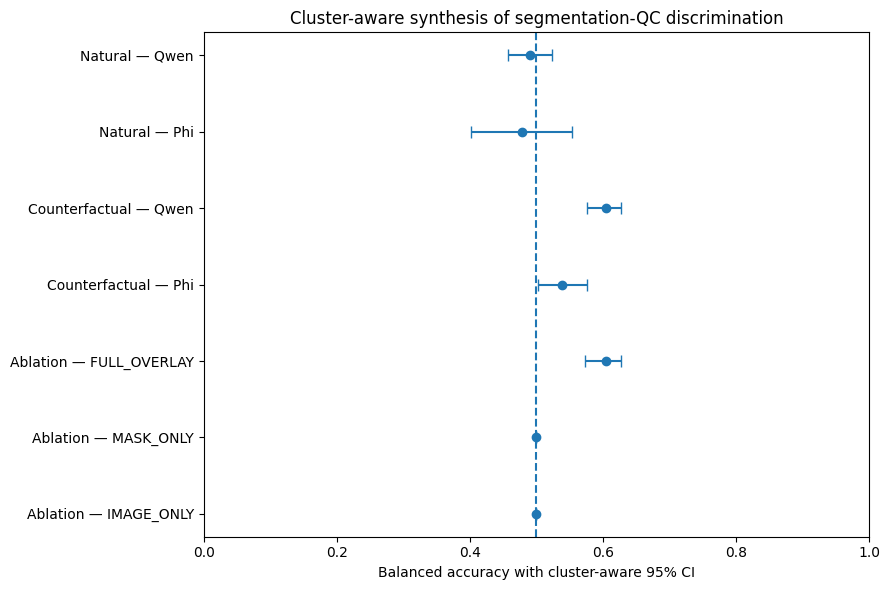

,experiment,model_or_view,balanced_accuracy,ba_ci95_low,ba_ci95_high,auroc,auroc_ci95_low,auroc_ci95_high,sensitivity,specificity
0,Natural SAM failure recognition,Qwen2.5-VL-7B,0.490330,0.457994,0.523458,0.475122,0.421057,0.530522,0.926606,0.054054
1,Natural SAM failure recognition,Phi-3.5-Vision,0.478015,0.401554,0.553751,0.480784,0.390241,0.569894,0.559633,0.396396
2,Controlled counterfactual QC,Qwen2.5-VL-7B,0.604444,0.575556,0.626667,0.604444,0.575556,0.626667,0.897778,0.311111
3,Controlled counterfactual QC,Phi-3.5-Vision,0.539182,0.502127,0.576216,0.527720,0.476158,0.580099,0.962085,0.116279
4,Qwen visual-evidence ablation,FULL_OVERLAY,0.604444,0.573333,0.626667,0.604444,0.573333,0.626667,0.897778,0.311111
5,Qwen visual-evidence ablation,MASK_ONLY,0.500000,0.500000,0.500000,0.552049,0.522414,0.585733,1.000000,0.000000
6,Qwen visual-evidence ablation,IMAGE_ONLY,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.533333,0.466667


Saved tables to: /content/drive/MyDrive/MedReasoner_SAM_2026/07_statistical_synthesis_fast
Saved figure: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/07_FAST_cluster_aware_balanced_accuracy_synthesis.png


In [15]:
# CELL 15 — Publication-ready tables and figures
def metric_row(table,selector,metric):
    x=table.copy()
    for c,v in selector.items():x=x[x[c]==v]
    return x[x["metric"]==metric].iloc[0]

headline=[]
for experiment,table,models in [("Natural SAM failure recognition",natural_cluster_ci,["Qwen2.5-VL-7B","Phi-3.5-Vision"]),("Controlled counterfactual QC",cf_cluster_ci,["Qwen2.5-VL-7B","Phi-3.5-Vision"])]:
    for model in models:
        ba=metric_row(table,{"model":model},"balanced_accuracy"); auc=metric_row(table,{"model":model},"auroc"); sens=metric_row(table,{"model":model},"sensitivity"); spec=metric_row(table,{"model":model},"specificity")
        headline.append({"experiment":experiment,"model_or_view":model,"balanced_accuracy":ba["estimate"],"ba_ci95_low":ba["cluster_ci95_low"],"ba_ci95_high":ba["cluster_ci95_high"],"auroc":auc["estimate"],"auroc_ci95_low":auc["cluster_ci95_low"],"auroc_ci95_high":auc["cluster_ci95_high"],"sensitivity":sens["estimate"],"specificity":spec["estimate"]})
for view in ["FULL_OVERLAY","MASK_ONLY","IMAGE_ONLY"]:
    ba=metric_row(ablation_cluster_metrics,{"view":view},"balanced_accuracy"); auc=metric_row(ablation_cluster_metrics,{"view":view},"auroc"); sens=metric_row(ablation_cluster_metrics,{"view":view},"sensitivity"); spec=metric_row(ablation_cluster_metrics,{"view":view},"specificity")
    headline.append({"experiment":"Qwen visual-evidence ablation","model_or_view":view,"balanced_accuracy":ba["estimate"],"ba_ci95_low":ba["cluster_ci95_low"],"ba_ci95_high":ba["cluster_ci95_high"],"auroc":auc["estimate"],"auroc_ci95_low":auc["cluster_ci95_low"],"auroc_ci95_high":auc["cluster_ci95_high"],"sensitivity":sens["estimate"],"specificity":spec["estimate"]})
headline=pd.DataFrame(headline)

# save tables
headline.to_csv(SYNTH_DIR/"table_headline_cluster_aware_results.csv",index=False)
natural_cluster_ci.to_csv(SYNTH_DIR/"table_natural_cluster_metrics.csv",index=False)
natural_domain_metrics.to_csv(SYNTH_DIR/"table_natural_domain_cluster_metrics.csv",index=False)
cf_cluster_ci.to_csv(SYNTH_DIR/"table_counterfactual_cluster_metrics.csv",index=False)
type_cluster_metrics.to_csv(SYNTH_DIR/"table_counterfactual_error_type_cluster_metrics.csv",index=False)
ablation_cluster_metrics.to_csv(SYNTH_DIR/"table_ablation_cluster_metrics.csv",index=False)
ablation_contrasts.to_csv(SYNTH_DIR/"table_ablation_cluster_contrasts.csv",index=False)
base_condition_deltas.to_csv(SYNTH_DIR/"base_level_condition_probability_deltas.csv",index=False)
margin_summary.to_csv(SYNTH_DIR/"table_evidence_margin_summary.csv",index=False)
margin_contrasts.to_csv(SYNTH_DIR/"table_evidence_margin_contrasts.csv",index=False)
domain_heterogeneity.to_csv(SYNTH_DIR/"table_domain_corruption_heterogeneity.csv",index=False)

# synthesis figure
plot_rows=[]
for label,table,selector in [("Natural — Qwen",natural_cluster_ci,{"model":"Qwen2.5-VL-7B"}),("Natural — Phi",natural_cluster_ci,{"model":"Phi-3.5-Vision"}),("Counterfactual — Qwen",cf_cluster_ci,{"model":"Qwen2.5-VL-7B"}),("Counterfactual — Phi",cf_cluster_ci,{"model":"Phi-3.5-Vision"}),("Ablation — FULL_OVERLAY",ablation_cluster_metrics,{"view":"FULL_OVERLAY"}),("Ablation — MASK_ONLY",ablation_cluster_metrics,{"view":"MASK_ONLY"}),("Ablation — IMAGE_ONLY",ablation_cluster_metrics,{"view":"IMAGE_ONLY"})]:
    r=metric_row(table,selector,"balanced_accuracy"); plot_rows.append({"label":label,"estimate":r["estimate"],"low":r["cluster_ci95_low"],"high":r["cluster_ci95_high"]})
plot_df=pd.DataFrame(plot_rows); ypos=np.arange(len(plot_df)); fig,ax=plt.subplots(figsize=(9,6))
ax.errorbar(plot_df["estimate"],ypos,xerr=[plot_df["estimate"]-plot_df["low"],plot_df["high"]-plot_df["estimate"]],fmt="o",capsize=4); ax.axvline(.5,linestyle="--")
ax.set_yticks(ypos); ax.set_yticklabels(plot_df["label"]); ax.set_xlim(0,1); ax.set_xlabel("Balanced accuracy with cluster-aware 95% CI"); ax.set_title("Cluster-aware synthesis of segmentation-QC discrimination"); ax.invert_yaxis(); plt.tight_layout()
BA_FIG=FIG_DIR/"07_FAST_cluster_aware_balanced_accuracy_synthesis.png"; plt.savefig(BA_FIG,dpi=220,bbox_inches="tight"); plt.show()

display(headline)
print("Saved tables to:",SYNTH_DIR)
print("Saved figure:",BA_FIG)

In [16]:
# CELL 16 — Final scientific summary
summary={
    "analysis":"fast_cluster_aware_statistical_synthesis",
    "seed":SEED,
    "cluster_bootstrap_draws":N_BOOT,
    "permutation_draws":N_PERM,
    "cluster_units":{"natural_sam":"domain + case_id","counterfactual":"base_id","evidence_ablation":"base_id"},
    "natural_rows":int(len(nq)),
    "natural_independent_clusters":int(nq["natural_cluster"].nunique()),
    "counterfactual_rows":int(len(cq)),
    "counterfactual_independent_base_images":int(cq["base_id"].nunique())
}
SUMMARY_PATH=SYNTH_DIR/"07_FAST_cluster_aware_synthesis_summary.json"; SUMMARY_PATH.write_text(json.dumps(summary,indent=2))
print("="*94); print("FAST CLUSTER-AWARE STATISTICAL SYNTHESIS COMPLETE"); print("="*94)
print("\nHeadline results"); display(headline)
print("\nNatural Qwen minus Phi"); display(natural_model_contrasts)
print("\nCounterfactual Qwen minus Phi"); display(cf_model_contrasts)
print("\nEvidence-ablation contrasts"); display(ablation_contrasts)
print("\nRisk-quality correlations"); display(pd.concat([natural_correlations.assign(experiment="natural"),cf_correlations.assign(experiment="counterfactual"),ablation_correlations.assign(experiment="ablation")],ignore_index=True,sort=False))
print("\nBase-matched evidence margins"); display(margin_summary)
print("\nEvidence-margin paired contrasts"); display(margin_contrasts)
print("\nDomain x corruption heterogeneity"); display(domain_heterogeneity)
print("\nSummary saved:",SUMMARY_PATH)

FAST CLUSTER-AWARE STATISTICAL SYNTHESIS COMPLETE

Headline results


,experiment,model_or_view,balanced_accuracy,ba_ci95_low,ba_ci95_high,auroc,auroc_ci95_low,auroc_ci95_high,sensitivity,specificity
0,Natural SAM failure recognition,Qwen2.5-VL-7B,0.490330,0.457994,0.523458,0.475122,0.421057,0.530522,0.926606,0.054054
1,Natural SAM failure recognition,Phi-3.5-Vision,0.478015,0.401554,0.553751,0.480784,0.390241,0.569894,0.559633,0.396396
2,Controlled counterfactual QC,Qwen2.5-VL-7B,0.604444,0.575556,0.626667,0.604444,0.575556,0.626667,0.897778,0.311111
3,Controlled counterfactual QC,Phi-3.5-Vision,0.539182,0.502127,0.576216,0.527720,0.476158,0.580099,0.962085,0.116279
4,Qwen visual-evidence ablation,FULL_OVERLAY,0.604444,0.573333,0.626667,0.604444,0.573333,0.626667,0.897778,0.311111
5,Qwen visual-evidence ablation,MASK_ONLY,0.500000,0.500000,0.500000,0.552049,0.522414,0.585733,1.000000,0.000000
6,Qwen visual-evidence ablation,IMAGE_ONLY,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.533333,0.466667



Natural Qwen minus Phi


,comparison,metric,estimate_difference,cluster_ci95_low,cluster_ci95_high,bootstrap_probability_gt_0
0,Qwen minus Phi,balanced_accuracy,0.012315,-0.065291,0.085003,0.5980
1,Qwen minus Phi,auroc,-0.005662,-0.095639,0.083362,0.4535



Counterfactual Qwen minus Phi


...


Evidence-margin paired contrasts


,contrast,mean_margin_difference,bootstrap_ci95_low,bootstrap_ci95_high,sign_flip_p,n_bases,sign_flip_p_bh
0,FULL_OVERLAY minus MASK_ONLY,0.121556,0.050444,0.194450,0.0029,45,0.0029
1,FULL_OVERLAY minus IMAGE_ONLY,0.146222,0.077778,0.220889,0.0003,45,0.0006
2,MASK_ONLY minus IMAGE_ONLY,0.024667,0.012444,0.036667,0.0004,45,0.0006



Domain x corruption heterogeneity


,condition,permutation_F,p_value,n_bases,p_bh
0,OVERSEGMENTATION,22.891892,0.000100,45,0.000167
1,PARTIAL_MISSING,196.000000,0.000100,45,0.000167
2,SHIFT,9.333333,0.001500,45,0.001875
3,UNDERSEGMENTATION,1.909091,0.288371,45,0.288371
4,WRONG_REGION,91.000000,0.000100,45,0.000167



Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/07_statistical_synthesis_fast/07_FAST_cluster_aware_synthesis_summary.json
